## Paso 1. Preparación inicial

1. Cargar librerías para trabajar con la información

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
# Cargar los datos de Ice
df = pd.read_csv("games.csv")

1.1 Examinar los datos llamando los siguientes métodos
* info() -> revisión de información general
* head() -> para visualizar las primeras lineas

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [84]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Observaciones

En el DataFrame se visualiza lo siguiente:
* 16,715 filas y 11 columnas
* Columnas:  en mayúsculas y minúsculas 
* Tipo de datos: float para year of realse en lugar de int64 | object para user_score en lugar de float64
* Valores ausentes: datos ausentes en las columnas (name, year_of_release, genre, critic_score, user_score, rating)

## Paso 2. Preparar datos

* 2.1 Remplazar los nombres de las columnas (colocarlos en minúsculas).
* 2.2 Convertir los datos en los tipos de datos necesarios, year_of_release en entero ya que habla del año de lanzamiento // user_score en float ya que los esta tomando como str
* 2.3 Tratar valores ausentes en: name, year_of_release, genre, critic_score, user_score, rating


In [85]:
# Visualizar nombre de las columnas
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [86]:
# 2.1 Convertir el nombre de las columnas a minúsculas y verificar si se realizó el cambio
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

* Antes de realizar el cambio de tipo de datos, vizualizar que información contienen las columnas y tratar los datos de la mejor manera.

In [87]:
# Visualizar valores únicos y faltantes
print(df["year_of_release"].unique())
print(f"\nValores faltantes: {df['year_of_release'].isnull().sum()}")

[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2016. 2003. 1986. 2000.   nan 1995. 1991. 1981. 1987.
 1980. 1983.]

Valores faltantes: 269


In [88]:
print(df["user_score"].unique())
print(f"\nValores faltantes: {df['user_score'].isnull().sum()}")

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']

Valores faltantes: 6701


In [89]:
# Convertir a tipo de datos float64 la columna user_score

df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce")

# Convertir a tipo de datos Int64 en la columna year_of_release

df["year_of_release"] = df["year_of_release"].astype("Int64")

### Valores ausentes

In [90]:
# Reemplazar "tbd" con Nan en user_score

df["user_score"] = df["user_score"].replace("tbd", np.nan)

In [91]:
# Validar valores ausentes en "name" y "genre"
df[df["name"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [92]:
# Eliminar los NaN de name y genre
df_clean = df[df["name"].notna()].copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


## Obeservaciones

En las primeras lineas podemos observar que existen valores "tbd" en la columna user_score, lo que significa to be determinated (por determinar), es decir que no hay información disponible ya que los usuarios aún no han dado su puntuación lo que en el DF podríamos tratarlo como un valor ausente, por tanto, remplazamos tbd por NaN

Para el caso de year_of_relase realizamos la conversión a tipo entero donde pandas pueda permitir valores ausentes, en este sentido con "Int64". 
No se realiza remplazo de los NaN por "0" ya que podría afectar al análisis dado que no es un dato real.

VALORES AUSENTES para la columna "name" y "genre", se muestran únicamente 2 filas que contienen valores ausentes; se decide eliminar esta información ya que no representa un porcentaje significativo asi como el año de lanzamiento en la plataforma GEN que pudiera servir para nuestro análisis.

## Ventas totales

Calcular las ventas totales (la suma de las ventas en todas las regiones) para cada juego, colocandolo en una columna separada

In [93]:
df_clean["venta_total"] = df_clean[["na_sales", "eu_sales", "jp_sales", "other_sales"]].sum(axis=1)
df_clean.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,venta_total
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


### Paso 3. Análisis de datos

<Axes: title={'center': 'Juegos lanzados por año'}, xlabel='año de lanzamiento', ylabel='juegos'>

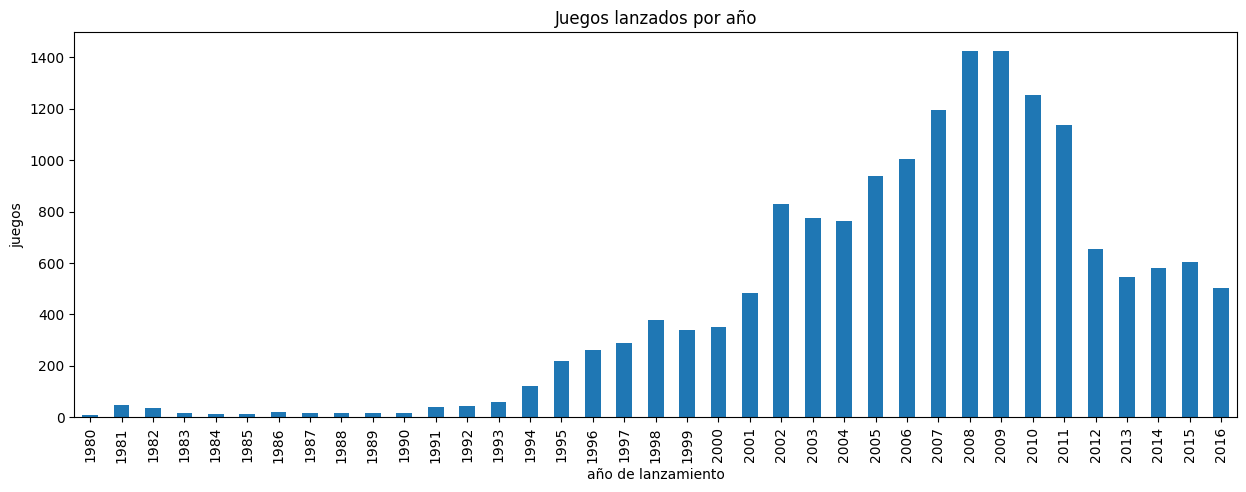

In [94]:
# Juegos lanzados en diferentes años ¿Son significativos los datos de cada periodo?
df_clean.groupby(["year_of_release"])["name"].count().plot(figsize= (15,5), kind= "bar", title = "Juegos lanzados por año", xlabel = "año de lanzamiento", ylabel = "juegos")

Los juegos lanzados a partir del 95 comienza a volverse significativo, con un incremento de lanzamientos de videojuegos por año, teniendo un primer pico en el 2002 y 6 años después superando los 1400 juegos lanzados para nuevamente disminuir los lanzamientos, sin embargo se mantienen por encima de los 600 lanzamientos.
 

<Axes: title={'center': 'Venta de juegos por plataforma'}, xlabel='Plataforma', ylabel='Ventas totales'>

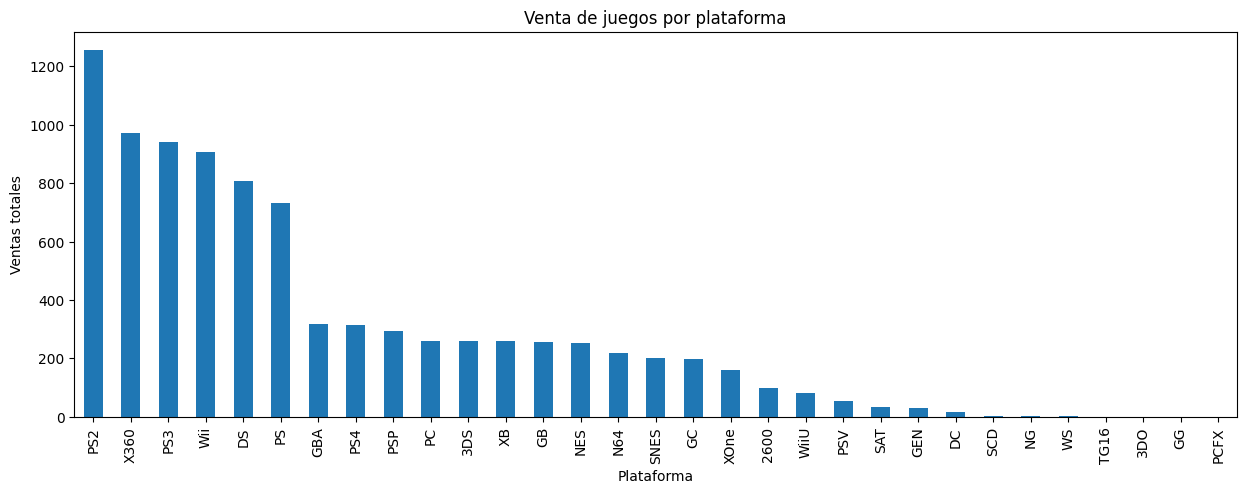

In [95]:
# Observaremos cómo varían las ventas de una plataforma a otra
df_clean.groupby(["platform"])["venta_total"].sum().sort_values(ascending = False).plot(figsize= (15,5), kind= "bar", title = "Venta de juegos por plataforma", xlabel = "Plataforma", ylabel = "Ventas totales")

Las plataformas de videojuegos que lideran las ventas son:
* PS2
* X360
* PS3
* Wii
* DS
* PS

In [96]:
# Elección de las plataformas con mayores ventas totales
top_venta = ["PS2", "X360", "PS3", "Wii", "DS", "PS"]
df_top_venta = df_clean[df_clean["platform"].isin(top_venta)]

#Comprobar que sólo estén filtradas las plataformas de la variable "top_venta"
df_top_venta["platform"].unique()

array(['Wii', 'DS', 'X360', 'PS3', 'PS2', 'PS'], dtype=object)

In [97]:
# Construcción de una distribución basada en los datos de cada año
df_ventas = df_top_venta.groupby(["platform", "year_of_release"])["venta_total"].sum().reset_index()
df_ventas.head()

,platform,year_of_release,venta_total
0,DS,1985,0.02
1,DS,2004,17.27
2,DS,2005,130.14
3,DS,2006,119.81
4,DS,2007,146.94


<function matplotlib.pyplot.show(close=None, block=None)>

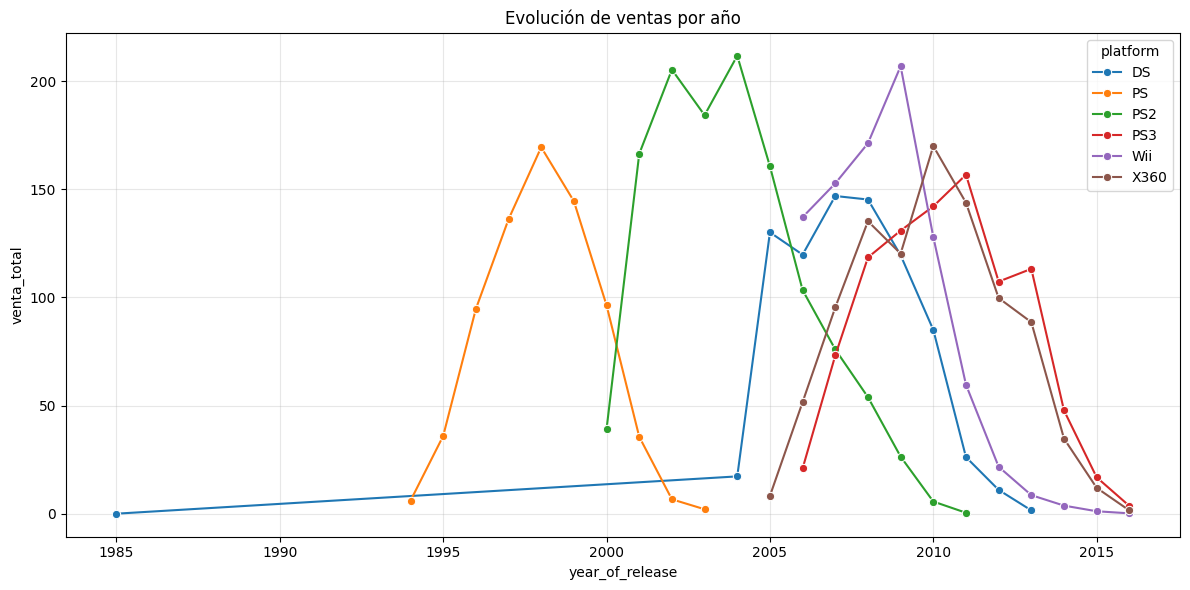

In [98]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_ventas, x="year_of_release", y="venta_total", hue="platform", marker="o")
plt.title("Evolución de ventas por año")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show

Podemos observar que el comportamiento de venta de las plataformas seleccionadas, en las cuales 4 de ellas muestran 2 ciclos de venta antes de una caíada en venta, asi mismo, entre el año 2004 al 2010; cuando aparece una nueva plataforma las que ya existían en el mercado, sus ventas comienzan a disminuir mientras la nueva va en incremento.

In [99]:
# Busqueda de las plataformas que solían ser populares pero que ahora no tienen ventas.

duracion_platform = df_clean.groupby("platform").agg(
    año_inicio = ("year_of_release", "min"),
    año_fin = ("year_of_release", "max")
).reset_index()

duracion_platform["duracion"] = duracion_platform["año_fin"] - duracion_platform["año_inicio"]
print(duracion_platform.sort_values("año_inicio", ascending = True))

   platform  año_inicio  año_fin  duracion
0      2600        1980     1989         9
11      NES        1983     1994        11
13       PC        1985     2016        31
4        DS        1985     2013        28
5        GB        1988     2001        13
8       GEN        1990     1994         4
23     SNES        1990     1999         9
9        GG        1992     1992         0
22      SCD        1993     1994         1
12       NG        1993     1996         3
1       3DO        1994     1995         1
15       PS        1994     2003         9
21      SAT        1994     1999         5
24     TG16        1995     1995         0
10      N64        1996     2002         6
14     PCFX        1996     1996         0
3        DC        1998     2008        10
25       WS        1999     2001         2
6       GBA        2000     2007         7
29       XB        2000     2008         8
16      PS2        2000     2011        11
7        GC        2001     2007         6
19      PSP

In [100]:
promedio_duracion = duracion_platform["duracion"].mean()
print(promedio_duracion)

7.612903225806452


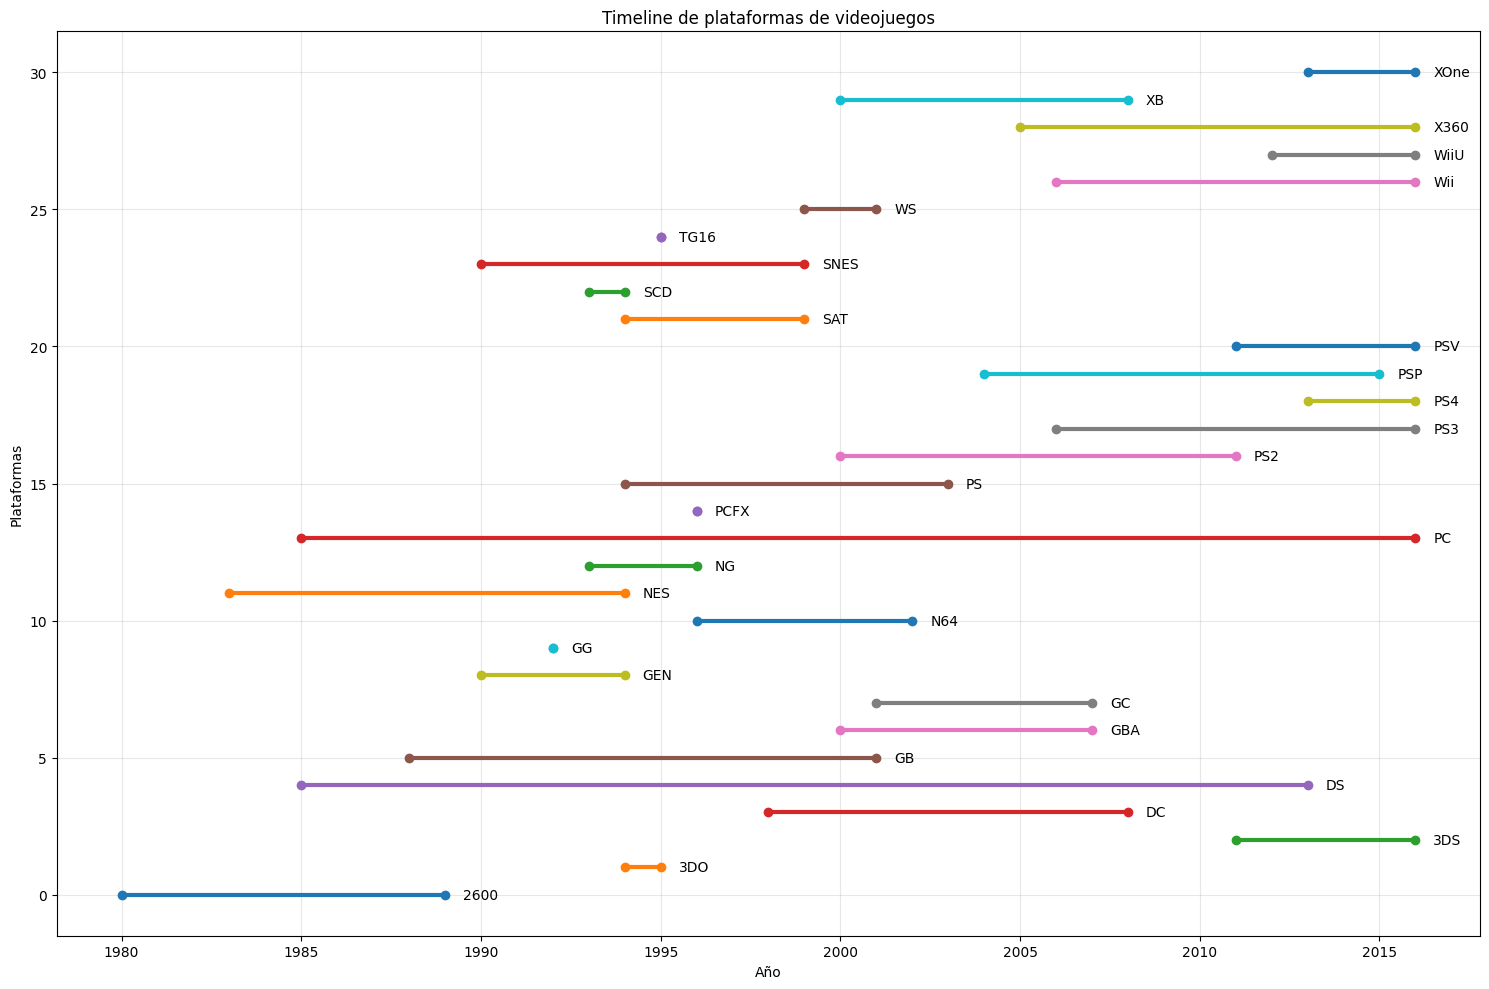

In [101]:
plt.figure(figsize=(15, 10))
for i, row in duracion_platform.iterrows():
    plt.plot([row["año_inicio"], row["año_fin"]], [i, i], 'o-', linewidth=3, markersize=6)
    plt.text(row["año_fin"] + 0.5, i, row["platform"], va='center')

plt.xlabel("Año")
plt.ylabel("Plataformas")
plt.title("Timeline de plataformas de videojuegos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Observaciones: De forma general podemos describrir que en promedio una plataforma tiene una duración en el mercado de 7 años y medio. Sin embargo, en nuestro top en ventas, esas plataformas llevan liderando las ventas más de 8 años y que aún siguen vigentes al 2016.
Por otro lado PS, ha sido una de las plataformas populares en ventas pero para el 2003 desapareció. 

De acuerdo a la información mostrada, para el siguiente análisis se considerarán fechas a partir del año 2012 para proyección del 2017.

In [102]:
#Trabajar solo con datos de hasta 4 años de atigüedad.
df_reciente = df_clean[df_clean["year_of_release"] >= 2012].reset_index()

<Axes: title={'center': 'Venta de juegos por plataforma'}, xlabel='Plataforma', ylabel='Ventas totales'>

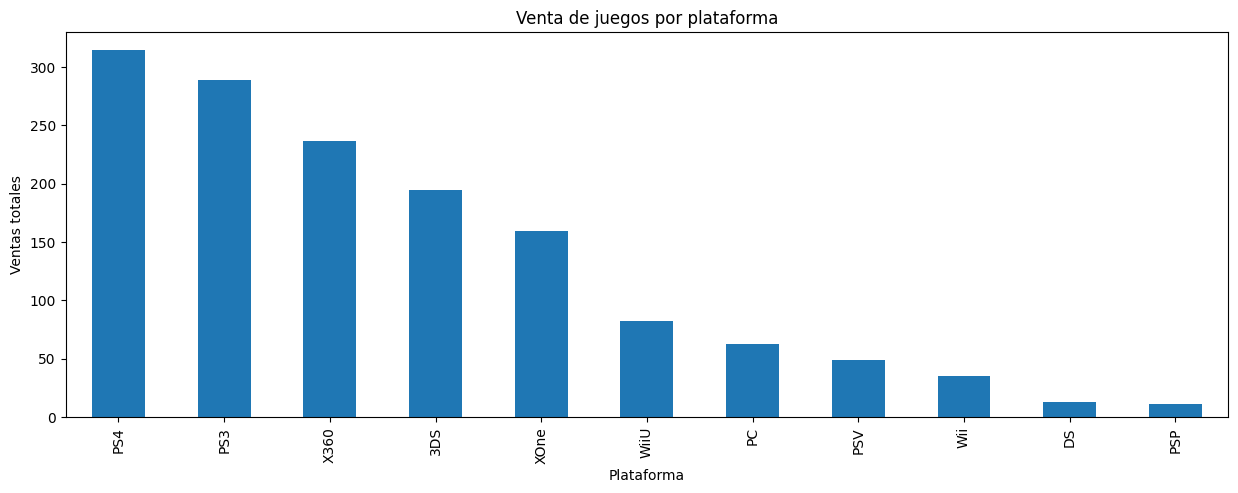

In [103]:
df_reciente.groupby(["platform"])["venta_total"].sum().sort_values(ascending = False).plot(figsize= (15,5), kind= "bar", title = "Venta de juegos por plataforma", xlabel = "Plataforma", ylabel = "Ventas totales")


Las plataformas líderes en ventas son: 
-PS4
-PS3
-X360

Las plataformas que aún se encuentran en el top 5 son: PS3, X360, incorporandose PS4 como lider en ventas y en la 4ta posición 3DS y 5ta posición XOne.
Por otro lado PS2 que antes era la número 1 en ventas ahora ya no se encuentra entre las primeras 10 posiciones.

In [104]:
#Elección de plataformas potencialmente rentables (top 5)
platform_ren = ["PS4", "PS3", "X360", "3DS", "XOne"]
df_top = df_reciente[df_reciente["platform"].isin(platform_ren)]
df_top.head()

,index,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,venta_total
0,16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
1,23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
2,31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
3,33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
4,34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79


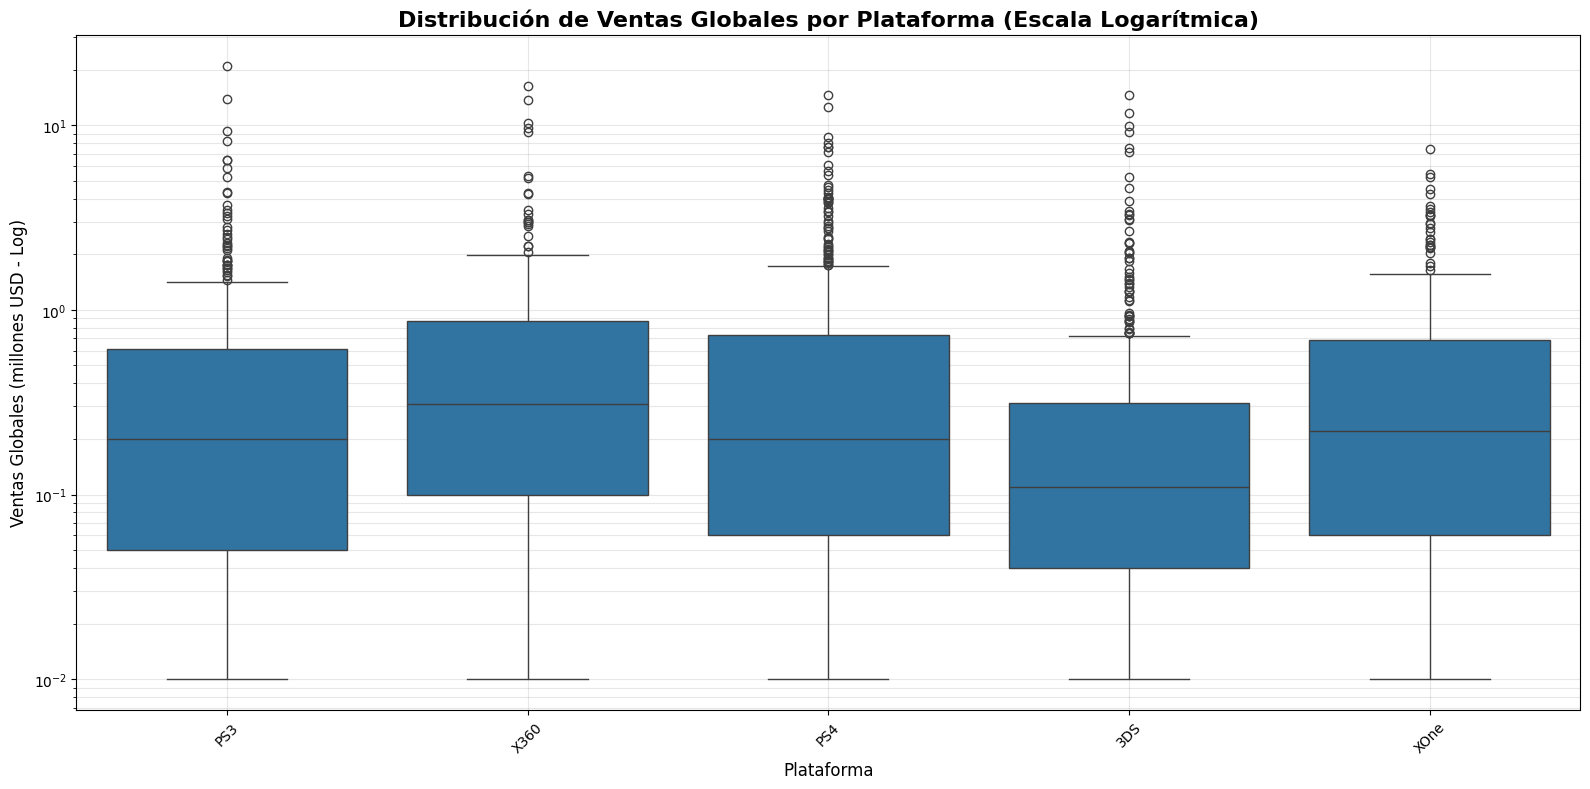

In [105]:
#Diagrama de caja para observar las ventas globales de todos los juegos, desglosados por plataforma.
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_top, x="platform", y="venta_total")
plt.yscale("log")
plt.title("Distribución de Ventas Globales por Plataforma (Escala Logarítmica)", fontsize=16, fontweight='bold')
plt.xlabel("Plataforma", fontsize=12)
plt.ylabel("Ventas Globales (millones USD - Log)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, which="both", ls="-")
plt.tight_layout()
plt.show()

In [106]:
estadistica_platform = df_top.groupby("platform")["venta_total"].agg([
    "mean", "median", "std", "count"
    ]).round(2)
print("ESTADÍSTICAS DE PLATAFORMA")
print(estadistica_platform.sort_values("mean", ascending=False))

ESTADÍSTICAS DE PLATAFORMA
          mean  median   std  count
platform                           
X360      0.81    0.31  1.71    292
PS4       0.80    0.20  1.61    392
XOne      0.65    0.22  1.04    247
PS3       0.59    0.20  1.46    493
3DS       0.49    0.11  1.39    396


¿Son significativas las diferencias en las ventas? 

Existen diferencias aparentes entre plataformas como X360 y PS4 con 3DS en las que de acuerdo a la mediana 3DS tiene ventas más bajas; sin embargo la desviasión estándar de X360 y PS4 son altas 

¿Qué sucede con las ventas promedio en varias plataformas?

Observando las ventas promedio, X360, PS4 son algo similares, XOne, PS3 y 3DS son menores, lo que ha simple vista diriamos que unas plataformas venden más que otras; sin embargo, considerando la mediana todas son menores a la media lo que nos puede indicar que hay juegos que han sido muy existoso que puede incrementar el promedio en las ventas.


* Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular

In [107]:
# Filtrar datos para X360 y eliminar valores ausentes
x360_data = df_top[df_top["platform"] == "X360"].copy()
x360_clean = x360_data.dropna(subset=["critic_score", "user_score", "venta_total"])
x360_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 1 to 2847
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            171 non-null    int64  
 1   name             171 non-null    object 
 2   platform         171 non-null    object 
 3   year_of_release  171 non-null    Int64  
 4   genre            171 non-null    object 
 5   na_sales         171 non-null    float64
 6   eu_sales         171 non-null    float64
 7   jp_sales         171 non-null    float64
 8   other_sales      171 non-null    float64
 9   critic_score     171 non-null    float64
 10  user_score       171 non-null    float64
 11  rating           170 non-null    object 
 12  venta_total      171 non-null    float64
dtypes: Int64(1), float64(7), int64(1), object(4)
memory usage: 18.9+ KB


* Creación de gráfico de dispersión para calcular la correlación entre las reseñas y las ventas

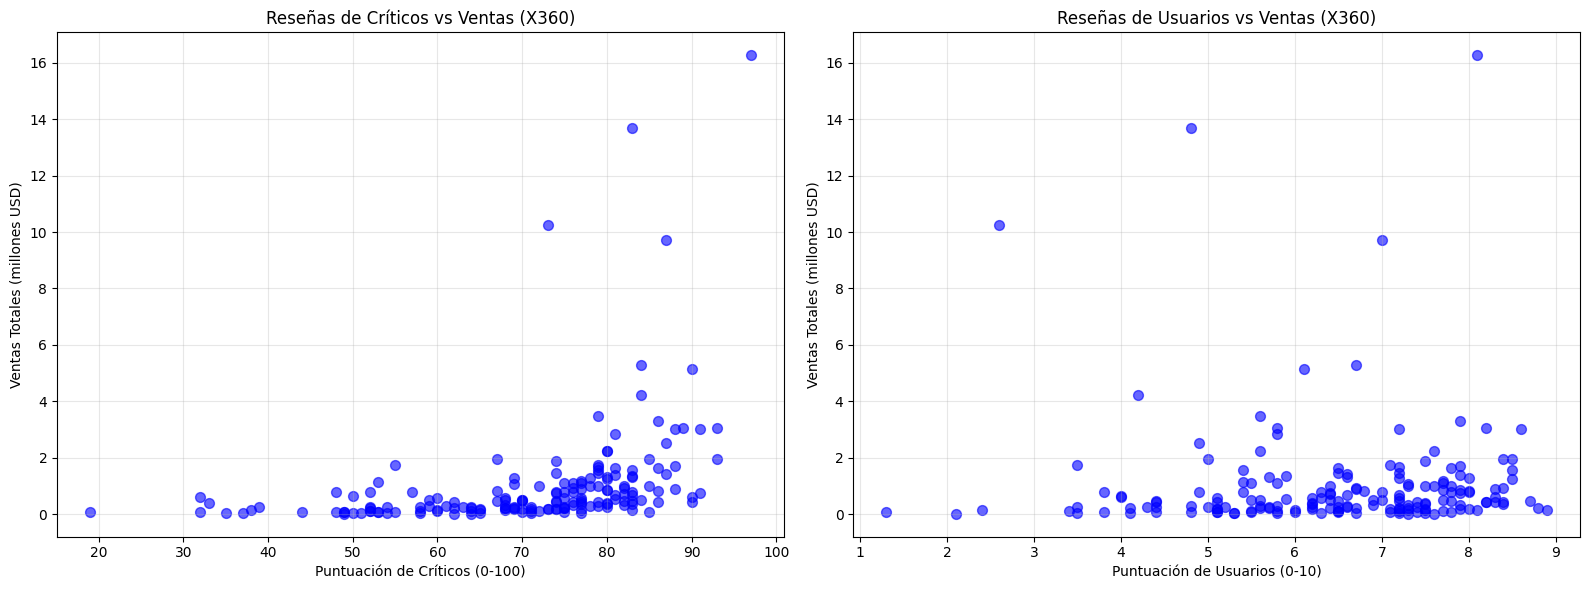

In [108]:
# Crear subplots para comparar ambas reseñas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Reseñas de críticos vs Ventas
ax1.scatter(x360_clean["critic_score"], x360_clean["venta_total"], 
           alpha=0.6, color='blue', s=50)
ax1.set_xlabel("Puntuación de Críticos (0-100)")
ax1.set_ylabel("Ventas Totales (millones USD)")
ax1.set_title("Reseñas de Críticos vs Ventas (X360)")
ax1.grid(True, alpha=0.3)

# Gráfico 1: Reseñas de usuarios vs Ventas

ax2.scatter(x360_clean["user_score"], x360_clean["venta_total"], 
           alpha=0.6, color='blue', s=50)
ax2.set_xlabel("Puntuación de Usuarios (0-10)")
ax2.set_ylabel("Ventas Totales (millones USD)")
ax2.set_title("Reseñas de Usuarios vs Ventas (X360)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
corr_critic = x360_clean["critic_score"].corr(x360_clean["venta_total"])
corr_user = x360_clean["user_score"].corr(x360_clean["venta_total"])
print("ANÁLISIS DE CORRELACIÓN:")
print(f"Correlación críticos vs ventas: {corr_critic}")
print(f"Correlación usuarios vs ventas: {corr_user}")

ANÁLISIS DE CORRELACIÓN:
Correlación críticos vs ventas: 0.36057348885073387
Correlación usuarios vs ventas: -0.0020140394826898196


Observaciones:
Al observar el gráfico de dispersión podemos decir que las ventas tienden a subir cuando la crítica de los profesionales dan un puntaje arriba de los 70 puntos, habiendo una correlación positiva; en el caso de la crítica de los usuarios si se visualiza una carga en ventas cuando el puntaje es alto sin embargo se visualizan más puntos dispersos. Lo que al hacer el análisis de correlación para ambos casos, tenemos que en efecto las reseñas de los profesionales influyen moderadamente las ventas, caso contrario de la crítica de los usuarios que la correlación con las ventas tiene poca influencia.

* Comparar las ventas de los mismos juegos en otras plataformas

In [110]:
# Encontrar juegos que están disponibles en multiples plataformas

juegos_multiplataforma = df_top.groupby("name").agg({
    "platform": "count",
    "venta_total": "sum"}).rename(columns={"platform": "num_plataformas"})

# Filtrar sólo juegos que están en 2 o más plataformas
juegos_multi = juegos_multiplataforma[juegos_multiplataforma["num_plataformas"] >= 2]
juegos_multi = juegos_multi.sort_values("venta_total", ascending=False)
print(juegos_multi.head(10))


                                num_plataformas  venta_total
name                                                        
Grand Theft Auto V                            4        55.41
Call of Duty: Black Ops II                    2        27.47
Call of Duty: Ghosts                          4        26.35
Call of Duty: Black Ops 3                     4        25.41
Call of Duty: Advanced Warfare                4        21.56
Minecraft                                     4        21.53
FIFA 16                                       4        16.10
FIFA 15                                       5        15.92
FIFA 14                                       5        15.08
FIFA Soccer 13                                3        13.62


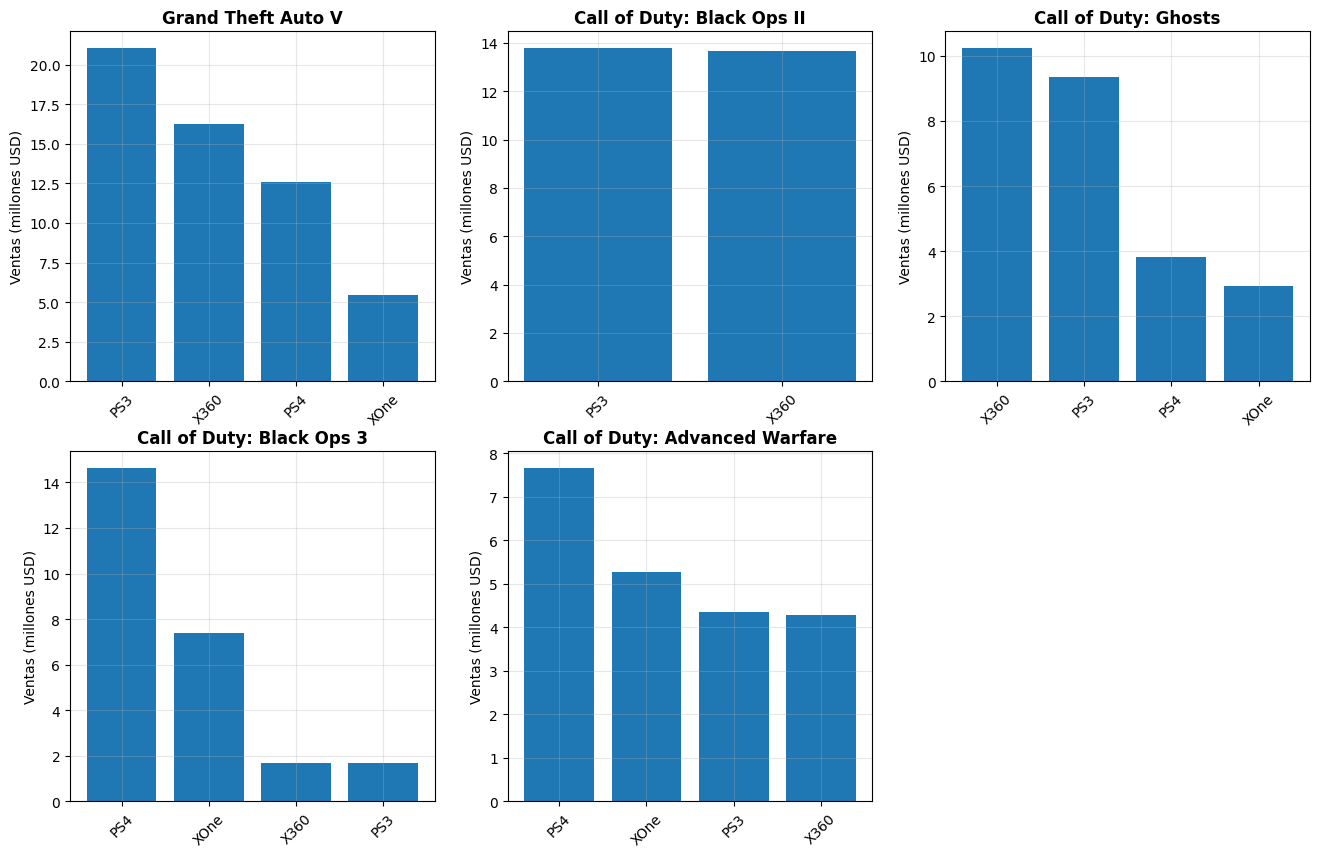

         venta_total                     
                mean  median    sum count
platform                                 
PS3           10.050   9.360  50.25     5
PS4            9.685  10.140  38.74     4
X360           9.234  10.240  46.17     5
XOne           5.260   5.365  21.04     4


In [111]:
# ANÁLISIS COMPARATIVO. Selección del top 5 y crear gráfico compartivo.

top_juegos = ["Grand Theft Auto V", "Call of Duty: Black Ops II", "Call of Duty: Ghosts", "Call of Duty: Black Ops 3", "Call of Duty: Advanced Warfare"]
df_comp = df_top[df_top["name"].isin(top_juegos)].copy()

plt.figure(figsize=(16,10))
for i, juego in enumerate(top_juegos):
    plt.subplot(2, 3, i+1)
    
    datos_juego = df_comp[df_comp["name"] == juego]
    plt.bar(datos_juego["platform"], datos_juego["venta_total"])
    
    plt.title(f"{juego}", fontsize=12, fontweight='bold')
    plt.ylabel("Ventas (millones USD)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
plt.show()

r_platform = df_comp.groupby("platform").agg({
    "venta_total": ["mean", "median", "sum", "count"]
})
print(r_platform.sort_values(("venta_total", "mean"), ascending=False))

Observaciones:
De acuerdo a los datos mostrados, las plataformas más populares continuan siendo X360, PS3, siendo una competencia directa por lo menos para los 3 primeros juegos. 
Podríamos especular que para PS4 y XOne la elección de la plataforma dependerá del tipo de juego y su disponibilidad ya que en el análisis de ranking de ventas, PS4 lidera las ventas pero dependiendo del juego puede estar entre las primeras elecciones o por detras de X360 o PS3; asi mismo con XOne será elegida de acuerdo al juego pero estando por debajo de PS4; por otro lado podemos observar que la plataforma 3DS no se encontró disponible, no por lo menos para estos top 5 de juegos que se pueden jugar en diferentes plataformas.

* Distribución general de los juegos por género.

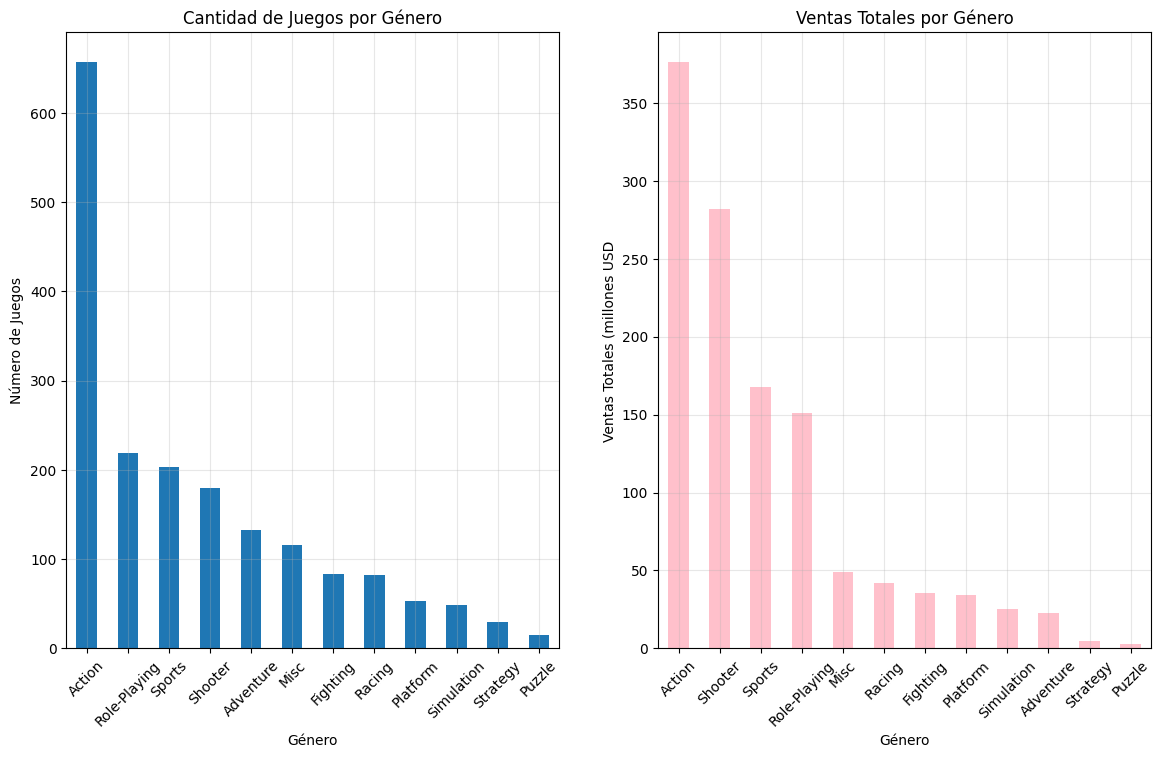

Top 5 Géneros por Cantidad:
genre
Action          657
Role-Playing    219
Sports          203
Shooter         180
Adventure       133
Name: count, dtype: int64

Top 5 Géneros por Ventas Totales:
genre
Action          376.25
Shooter         282.11
Sports          167.81
Role-Playing    151.26
Misc             48.78
Name: venta_total, dtype: float64


In [112]:
# Contar los juegos por género y visualizar la distribución
genero_count = df_top["genre"].value_counts()

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
genero_count.plot(kind="bar", title="Cantidad de Juegos por Género", xlabel="Género", ylabel="Número de Juegos")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

#Ventas totales por género
plt.subplot(1,2,2)
ventas_genero = df_top.groupby("genre")["venta_total"].sum().sort_values(ascending=False)
ventas_genero.plot(kind="bar", color="pink", title="Ventas Totales por Género", xlabel="Género", ylabel="Ventas Totales (millones USD")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

print("Top 5 Géneros por Cantidad:")
print(genero_count.head())
print()
print("Top 5 Géneros por Ventas Totales:")
print(ventas_genero.head())


In [113]:
j_ren = df_top.groupby("genre")["venta_total"].agg([
    "count",
    "sum",
    "mean",
    "median",
    "std"
]).round(2)
j_ren = j_ren.sort_values("mean", ascending=False)
print(j_ren)

              count     sum  mean  median   std
genre                                          
Shooter         180  282.11  1.57    0.58  2.49
Sports          203  167.81  0.83    0.39  1.26
Role-Playing    219  151.26  0.69    0.20  1.55
Platform         53   34.13  0.64    0.21  1.41
Action          657  376.25  0.57    0.17  1.42
Simulation       49   25.16  0.51    0.13  1.52
Racing           82   42.18  0.51    0.22  0.71
Fighting         83   35.53  0.43    0.18  0.90
Misc            116   48.78  0.42    0.15  1.08
Puzzle           15    2.72  0.18    0.07  0.27
Adventure       133   22.68  0.17    0.06  0.29
Strategy         30    4.79  0.16    0.08  0.16


OBSERVACIONES:

¿Qué se puede decir de los géneros más rentables? 
De acuerdo a las ventas totales Action, Shooter y Sports parecen ser los más rentables dado que tienen el mayor número de ventas totales, sin embargo si se visualiza el promedio en ventas, Shooter es el que tiene mejor promedio en ventas aunque su desviación estándar es alta, así como en el caso de Role-Playing, que ocupa el 3er lugar con uno de los mejores promedios en ventas, sin embargo su desviación estandar esta por debajo de Shooter; lo que podríamos decir que la venta depende de juegos que han sido extremadamente exitosos considerandolos como valores atípicos, por otro lado, si observamos los géneros como Puzzle, Adventure y Strategy el promedio en ventas es bajo así como la desviación estándar lo que pueden ser más predecibles sus ventas.

¿Se puede generalizar acerca de los géneros con ventas altas y bajas?
Géneros como Action y Shooter, tienen mayor potencial en ventas, pero no todo juego de estos géneros significa que va a vender bien. 
Por el contrario, strategy, puzzle y adventure son los géneros con ventas bajas pero no podemos decir que no puedan tener éxitos puntuales.  

### Paso 4. Perfil de usuario para cada región (NA, UE, JP)

* Determinar las cinco plataformas principales para cada región.
* Variaciones en cuotas de mercado de una región a otra.
* Top 5 de los géneros principales de cada región.
* Clasificaciones de ESRB ¿afectan a las ventas en regiones individuales?

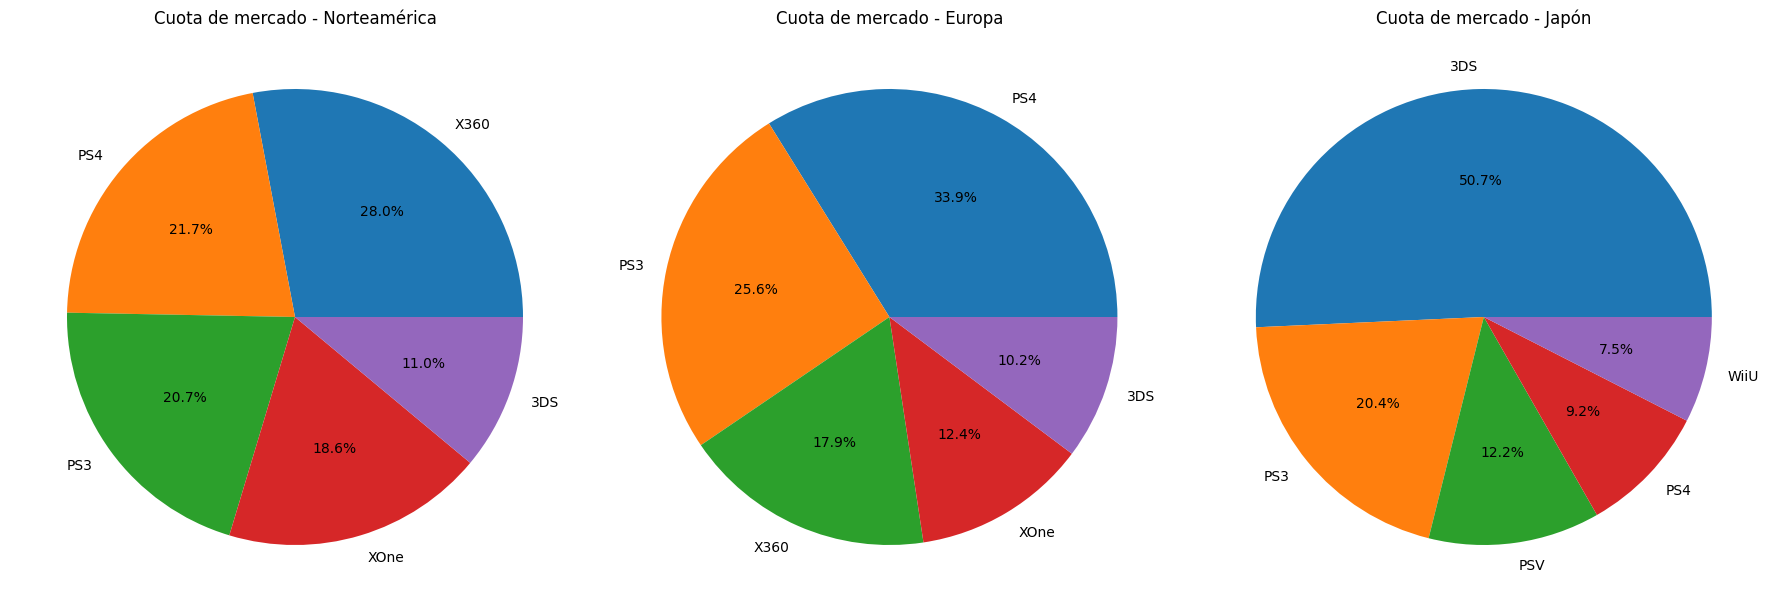

In [114]:
# top 5 de plataformas por región

ventas_na = df_reciente.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head()
ventas_eu = df_reciente.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head()
ventas_jp = df_reciente.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head()

#Gráfico comparativo
fig, axes = plt.subplots(1,3, figsize=(18,6))
# Norteamérica
axes[0].pie(ventas_na.head().values, labels=ventas_na.head().index, autopct='%1.1f%%')
axes[0].set_title("Cuota de mercado - Norteamérica")

# Europa
axes[1].pie(ventas_eu.values, labels=ventas_eu.index, autopct='%1.1f%%')
axes[1].set_title("Cuota de mercado - Europa")

# Japón
axes[2].pie(ventas_jp.values, labels=ventas_jp.index, autopct='%1.1f%%')
axes[2].set_title("Cuota de mercado - Japón")

plt.tight_layout()
plt.show()

In [115]:
print("CUOTA MERCADO - NORTEAMÉRICA:")
print(ventas_na)
print()
print("CUOTA MERCADO - EUROPA:")
print(ventas_eu)
print()
print("CUOTA MERCADO - JAPÓN:")
print(ventas_jp)

CUOTA MERCADO - NORTEAMÉRICA:
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

CUOTA MERCADO - EUROPA:
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

CUOTA MERCADO - JAPÓN:
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


OBSERVACIONES:

Visualizando las cuotas de mercado entre cada una de las regiones las ventas de las plataformas X360, PS4 y PS3 lideran el mercado en Norteamérica.
En Europa, PS4 esta por 1.04 millones de dolares por arriba de X360 y PS3 por 3.48 millones de dolares más que en NA pero no mayor que PS4.
Por lo que las ventas de videojuegos en estas plataformas provienen principalmente de estas dos regiones, pero para Japón X360 no esta dentro de las 5 principales plataformas, en su caso la de mayor preferencia esta por 3DS con 87.79, PS3 con 35.29 y en tercer lugar PSV con 21.04 MUSD. Cabe mencionar que estas cifras continuan estando por debajo de las principales cuotas en NA y EU.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1600x800 with 0 Axes>

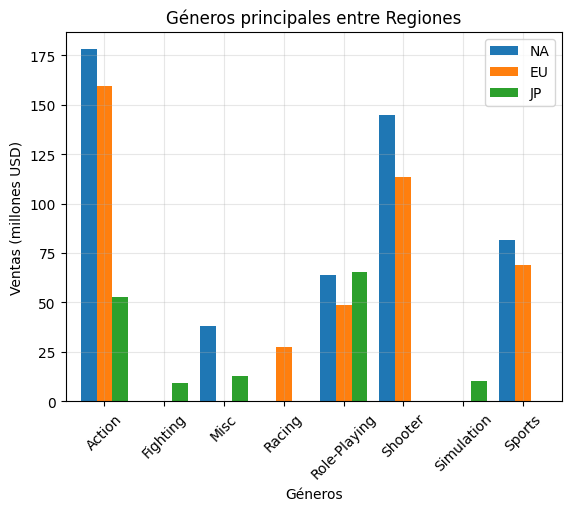

In [116]:
# Determinar los cinco géneros principales de cada región
genero_na = df_reciente.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head()
genero_eu = df_reciente.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head()
genero_jp = df_reciente.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head()

# Gráfico para mostrar comparación
df_generos_reg = pd.DataFrame({"NA": genero_na, "EU": genero_eu, "JP": genero_jp}).fillna(0)
plt.figure(figsize=(16,8))
df_generos_reg.plot(kind="bar", width=0.8, title="Géneros principales entre Regiones")
plt.xlabel("Géneros")
plt.ylabel("Ventas (millones USD)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show

OBSERVACIONES:

Podemos observar que tanto NA y EU comparten mismos géneros así como el orden de preferencia (por lo menos para los 4 primeros géneros para estas regiones), en el cual el género Action lidera, seguido de Shooter y Sports; por el contrario en JP, el género dominante es Role-Playing, y Action cae al segundo lugar, asimismo apareciendo géneros distinos como Misc, Simulation y Fighting; y Shooter quedando fuera del top para JP.
Mientras que Norteamérica y Europa presentan patrones muy similares, dominados por los géneros Action, Shooter y Sports, el mercado japonés muestra una orientación distinta, con un claro predominio de los juegos de Role-Playing. 
Podríamos sugerir que, aunque existen géneros con atractivo global como Action, el desempeño comercial de un género depende en gran medida del contexto regional y cultural, por lo que las estrategias de lanzamiento y desarrollo deben adaptarse a cada mercado.

<Figure size 1600x800 with 0 Axes>

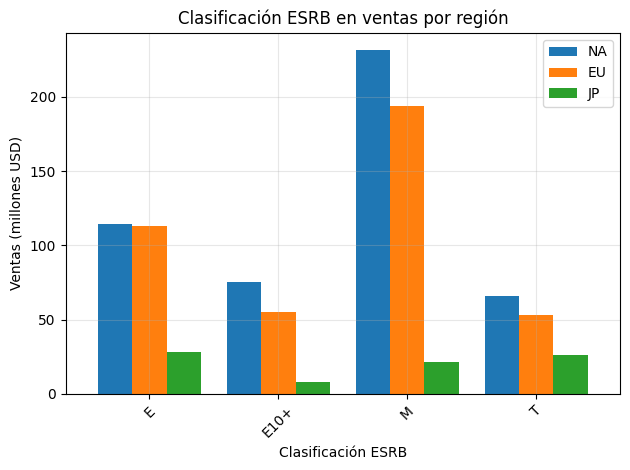

In [117]:
# Clasificaciones de ESRB.
rating_na = df_reciente.groupby("rating")["na_sales"].sum().sort_values(ascending=False)
rating_eu = df_reciente.groupby("rating")["eu_sales"].sum().sort_values(ascending=False)
rating_jp = df_reciente.groupby("rating")["jp_sales"].sum().sort_values(ascending=False)

df_rating_reg = pd.DataFrame({"NA": rating_na, "EU": rating_eu, "JP": rating_jp}).fillna(0)
plt.figure(figsize=(16,8))
df_rating_reg.plot(kind="bar", width=0.8, title="Clasificación ESRB en ventas por región")
plt.xlabel("Clasificación ESRB")
plt.ylabel("Ventas (millones USD)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [118]:
print("VENTAS POR CLASIFICACIÓN ESRB:")
print("\n NORTEAMÉRICA:")
print(rating_na)
print("\n EUROPA:")
print(rating_eu)
print("\n JAPÓN:")
print(rating_jp)

VENTAS POR CLASIFICACIÓN ESRB:

 NORTEAMÉRICA:
rating
M       231.57
E       114.37
E10+     75.70
T        66.02
Name: na_sales, dtype: float64

 EUROPA:
rating
M       193.96
E       113.03
E10+     55.37
T        52.96
Name: eu_sales, dtype: float64

 JAPÓN:
rating
E       28.33
T       26.02
M       21.20
E10+     8.19
Name: jp_sales, dtype: float64


OBSERVACIONES:

En Norteamérica y Europa los títulos clasificados como M y E concentran la mayor parte de las ventas, en Japón predominan las clasificaciones orientadas a públicos más amplios y jóvenes; sin embargo no podríamos decir que por si sola la clasificación ESRB cause mayores ventas dado que también dependera del género y la plataforma 

## Paso 5: Prueba de Hipótesis

Para realizar la prueba de hipótesis se utilizará un nivel de significacia del 5% (valor estándar).
Para realizar la prueba utilizaremos el metodo t de Student para comparar medias de dos grupos independientes, 2 plataformas y 2 géneros con una variable user_score.

Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

- H0: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
- HA: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son distintas.

Valor de significancia $\alpha$ = 0.05

In [119]:
# Filtrar plataformas por calificaciones
xbox_one = df_reciente[df_reciente["platform"] == "XOne"]["user_score"].dropna()
pc = df_reciente[df_reciente["platform"] == "PC"]["user_score"].dropna()

# Prueba de test
alpha = 0.05

from scipy import stats as st
_, pvalor = st.ttest_ind(xbox_one, pc)

if pvalor < alpha:
    print("Rechazamos H0:", pvalor)
else:
    print("No rechazamos H0:", pvalor)

No rechazamos H0: 0.5535080500643664


OBSERVACIONES:
Podemos decir que no hay evidencia suficiente para afirmar que las calificaciones promedio de los usuarios para Xbox One y PC son diferentes.

Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

- H0: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son las mismas.
- HA: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Valor de significancia $\alpha$ = 0.05

In [120]:
# Filtrar calificaciones por género
accion = df_reciente[df_reciente["genre"] == "Action"]["user_score"].dropna()
deportes = df_reciente[df_reciente["genre"] == "Sports"]["user_score"].dropna()

# Prueba de test
alpha = 0.05

from scipy import stats as st
_, pvalor = st.ttest_ind(accion, deportes)

if pvalor < alpha:
    print("Rechazamos H0:", pvalor)
else:
    print("No rechazamos H0:", pvalor)

Rechazamos H0: 3.7163089460934753e-26


OBSERVACIONES:
Existe evidencia suficiente para decir que las calificaciones promedio de los usuarios para los géneros Acción y Deportes sí son diferentes.

## Conclusiones

1. Tendencias del mercado de videojuegos:
* El mercado mostró crecimiento significativo desde el 95, con picos desde el 2002
* Las plataformas tien un ciclo de vida promedio de 7.5 años
* Para el 2017, las plataformas más prometedoras son: PS4, X360, PS3, Wii, DS y PS4

2. Análisis de Plataformas:
* X360 y PS4  tienen el mejor promedio de ventas (0.81 y 0.80 millones USD)
* XOne contante en el promedio de ventas con 0.65 MUSD aunque con el menor número de juegos.
* PS3 mantiene consistencia con buen volumen de juegos
* 3DS tiene menor promedio pero gran volumen de títulos.

** Factores de éxito:
- Las reseñas de críticos influyen moderadamente en las ventas (correlación 0.36)
- Las reseñas de usuarios tiene poca influencia (correlación -0.002)

3. Perfiles regionales:
* Norteamérica y Europa, preferencias similares (PS4, PS3 y X360), con géneros dominantes (action, shooter, sports) y clasificaciones ESRB (M y E) que lideran las ventas.
* En Japón tiene mercado único (3DS, PS3, PSV) X360 queda fuera del top 5 para esta región; el género dominante es "Role-Playing" muy diferente a occidente, y la preferencia por clasificaciones es E y T.

4. Géneros rentables:
* Con alto potencial queda en la lista Shooter con un promedio de ventas (1.57M USD), Action con un mayor volumen total de ventas y Sports el cual tiene un mejor equilibrio entre volumen y rentabilidad.
* Los géneros de menor riesgo, con ventas predecibles pero menores: Strategy, Puzzle y Adventure.

5. Recomendaciones para 2017
* Plataformas prioritarias: X360, PS4 y PS3 para mercados en NA y EU.
* 3DS y PS3, son esenciales para el mercado japonés.
* Globalmente los géneros más rentables Action y Shooter; para Japón role-playing.